# Wavelet transforms:
 https://pywavelets.readthedocs.io/en/latest/

## Example 1:

Let's carry out a DWT of this signal:

$f(n) = (2, 4, 6, 8, 9, -2, 3, -4)$ 

Then, carry out an inverse DWT to recover the signal.

In [1]:
import pywt
import matplotlib.pyplot as plt
import numpy as np

In [2]:
print(pywt.wavelist(kind = "discrete"))

['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'haar', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 'rbio2.8', 'rbio3.1', 'rbio3.3', 'rbio3.5', 'rbio3.7', 'rbio3.9', 'rbio4.4', 'rbio5.5', 'rbio6.8', 'sym2', 'sym3', 'sym4', 'sym5', 'sym6', 'sym7', 'sym8', 'sym9', 'sym10', 'sym11', 'sym12', 'sym13', 'sym14', 'sym15', 'sym16', 'sym17', 'sym18', 'sym19', 'sym20']


In [3]:

print(pywt.wavelist(kind = "continuous"))

['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']


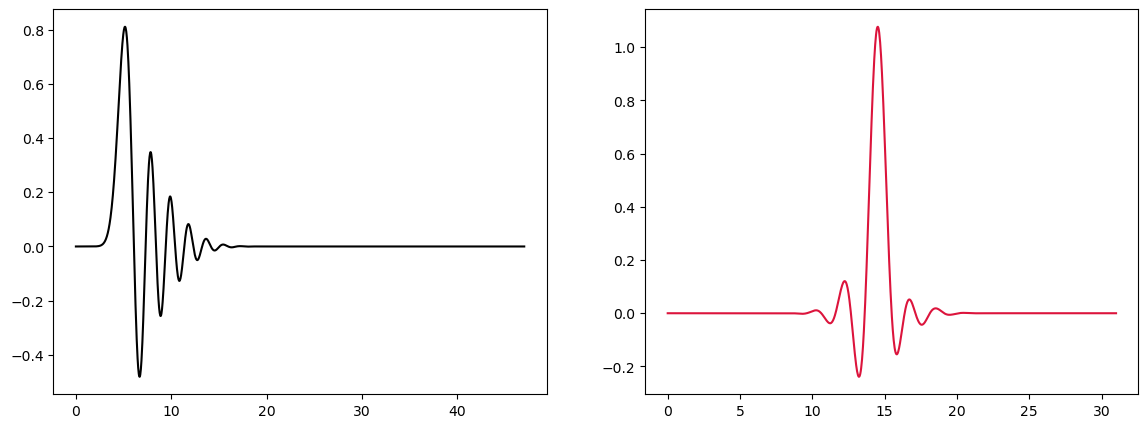

In [4]:
# 2 wavelets
w2 = pywt.Wavelet("db24") #get the properties
w3 = pywt.Wavelet("sym16")

# Plotting
# Gather information on wavelet
phi_2, psi_2, x_2 = w2.wavefun(level = 5)
phi_3, psi_3, x_3 = w3.wavefun(level = 5)

#print(phi_2.shape, phi_3.shape)

# Figure env
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))
ax1.plot(x_2, phi_2, color = "black")
ax2.plot(x_3, phi_3, color = "crimson")
plt.show()

In [5]:
# signal:

f = [2, 4, 6, 8, 9, -2, 3, -4, -7]

print(f, len(f))

[2, 4, 6, 8, 9, -2, 3, -4, -7] 9


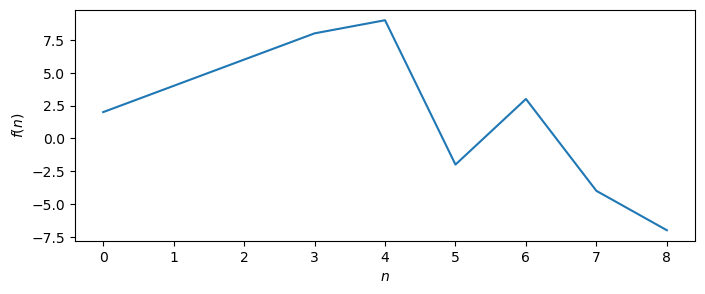

In [6]:
plt.figure(figsize=(8,3))

plt.plot(f)

plt.xlabel(r"$n$")

plt.ylabel(r"$f(n)$")

plt.show()

In [7]:
# DWT:

cA, cD = pywt.dwt(f, 'haar')

In [8]:
print(cA) # approximation coef.
print(cD) # detail coef.

[ 4.24264069  9.89949494  4.94974747 -0.70710678 -9.89949494]
[-1.41421356 -1.41421356  7.77817459  4.94974747  0.        ]


The coefficients arrays have the same size, which is approximately half the length of the signal on the 1st level.

### Full signal reconstruction:

In [9]:
# iDWT

f_recovered = pywt.idwt(cA, cD, 'haar')

In [10]:
print(f)
print(f_recovered) #we get an extra element if the len of the signal is not even

[2, 4, 6, 8, 9, -2, 3, -4, -7]
[ 2.  4.  6.  8.  9. -2.  3. -4. -7. -7.]


### Signal reconstruction with approximation/detail coefficients only:

In [11]:
# iDWT
# Only CA
f_ca = pywt.idwt(cA, None, 'haar')

# Only CD
f_cd = pywt.idwt(None, cD, 'haar')

In [12]:
print(f_ca)
print(f_ca.shape)

print(f_cd)
print(f_cd.shape)

[ 3.   3.   7.   7.   3.5  3.5 -0.5 -0.5 -7.  -7. ]
(10,)
[-1.   1.  -1.   1.   5.5 -5.5  3.5 -3.5  0.   0. ]
(10,)


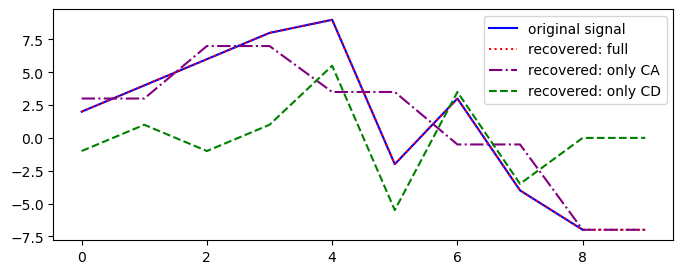

In [13]:
plt.figure(figsize=(8,3))

plt.plot(f, color = "blue", label= "original signal")

plt.plot(f_recovered, color = "red", linestyle = ":", label= "recovered: full")

plt.plot(f_ca, color = "purple", linestyle = "-.", label= "recovered: only CA")

plt.plot(f_cd, color = "green", linestyle = "--", label= "recovered: only CD")

plt.legend()
plt.show()

## Example 2:

$$f(x)= A\sin(k\,x) + b\,n(x)$$

In [14]:
# Pure sine function

def func(x_axis, a, k, b):
    """
    Inputs:
    a -> amplitude of the sine function
    k -> wavenumber
    b -> noise amplitude
    """
    f_sin = a*np.sin(k*x) + b*np.random.randn(len(x))
    
    return f_sin

In [15]:
# Generate x axis
x = np.linspace(0., 4*np.pi, 1000)

# Fix properties
a = 1.
k = 3./(np.pi)
b = 0.05

# Evaluate our function
noisy_sine = func(x, a, k, b)

print(x.shape, noisy_sine.shape)

(1000,) (1000,)


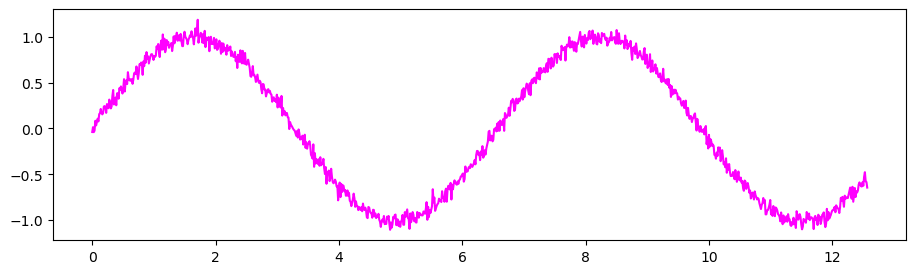

In [16]:
plt.figure(figsize=(11, 3))

plt.plot(x, noisy_sine, color = "magenta")

plt.show()

### Wavelet transforms:

In [17]:
# DWT:

cA, cD = pywt.dwt(noisy_sine, 'haar')

print(noisy_sine.shape, cA.shape, cD.shape)

(1000,) (500,) (500,)


### Reconstruct the full signal:

In [18]:
# iDWT

f_recovered = pywt.idwt(cA, cD, 'haar')

print(f_recovered.shape)

(1000,)


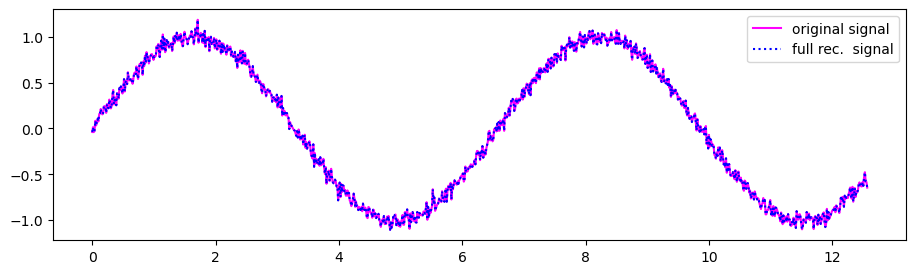

In [19]:
plt.figure(figsize=(11, 3))

plt.plot(x, noisy_sine, color = "magenta", label = "original signal")

plt.plot(x, f_recovered, linestyle = ":", color = "blue", label = "full rec.  signal")


plt.legend()

plt.show()

### Only low frequencies: Only with cA coefficients

In [20]:
# iDWT

f_ca = pywt.idwt(cA, None, 'haar')

print(x.shape, f_ca.shape)

(1000,) (1000,)


### Only high frequencies: Only with cD coefficients

In [21]:
# iDWT

f_cd = pywt.idwt(None, cD, 'haar')

print(f_cd.shape)

(1000,)


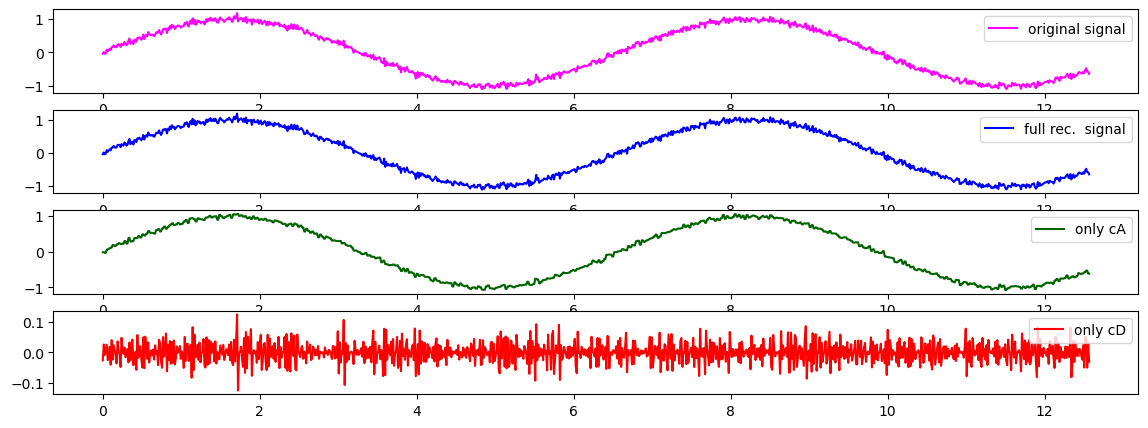

In [22]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize = (14,5))

ax1.plot(x, noisy_sine, color = "magenta", label = "original signal")
ax1.legend()

ax2.plot(x, f_recovered, linestyle = "-", color = "blue", label = "full rec.  signal")
ax2.legend()

ax3.plot(x, f_ca, linestyle = "-", color = "darkgreen", label = "only cA")
ax3.legend()

ax4.plot(x, f_cd, linestyle = "-", color = "red", label = "only cD")
ax4.legend()
plt.show()

### Second level of decomposition

In [23]:
# DWT:

cA2, cD2 = pywt.dwt(f_ca, 'haar') #we use the approximation coefficients (cA)

print(noisy_sine.shape, f_ca.shape)

(1000,) (1000,)


In [24]:
# iDWT

f_ca2 = pywt.idwt(cA2, None, 'haar')

f_cd2 = pywt.idwt(None, cD2, 'haar')

print(x.shape, f_ca2.shape, f_cd2.shape)

(1000,) (1000,) (1000,)


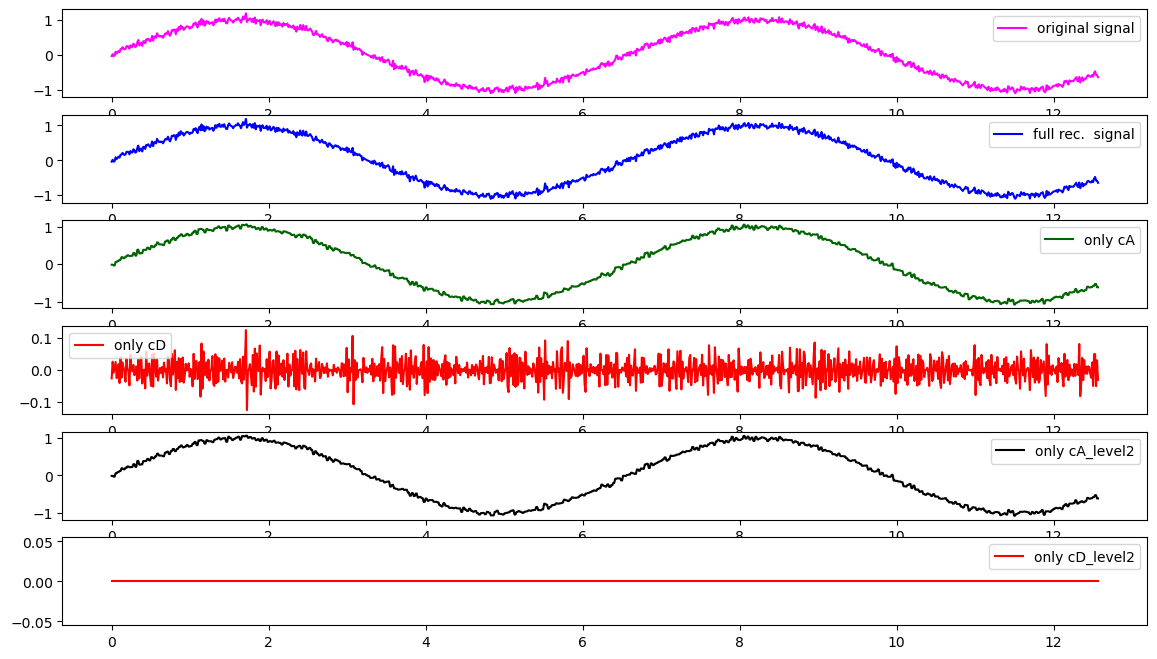

In [25]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize = (14,8))

ax1.plot(x, noisy_sine, color = "magenta", label = "original signal")
ax1.legend()

ax2.plot(x, f_recovered, linestyle = "-", color = "blue", label = "full rec.  signal")
ax2.legend()

ax3.plot(x, f_ca, linestyle = "-", color = "darkgreen", label = "only cA")
ax3.legend()

ax4.plot(x, f_cd, linestyle = "-", color = "red", label = "only cD")
ax4.legend()

ax5.plot(x, f_ca2, linestyle = "-", color = "black", label = "only cA_level2")
ax5.legend()

ax6.plot(x, f_cd2, linestyle = "-", color = "red", label = "only cD_level2") #should output values at 1e-17, but my machine is not that precise
ax6.legend()

plt.show()

## Wavelet transform analysis:

coeffs = pywt.wavedec(x, 'wavelet', mode ='sym', level = n)

y = pywt.waverec(coeffs, 'wavelet', mode ='sym')

https://pywavelets.readthedocs.io/en/latest/ref/dwt-discrete-wavelet-transform.html

### Revisit the first example:

In [26]:
print(f)

[2, 4, 6, 8, 9, -2, 3, -4, -7]


### DWT decomposition:

In [27]:
coeffs = pywt.wavedec(f, 'db1', level = 2, mode = 'periodic')

cA2, cD2, cD1 = coeffs

print(cA2)
print(cD2)
print(cD1)

[10.   3.   0.5]
[-4.   4.  -5.5]
[-1.41421356 -1.41421356  7.77817459  4.94974747 -6.36396103]


### DWT reconstruction:

In [28]:
f_recovered2 = pywt.waverec(coeffs, 'db1', mode = 'periodic')

In [29]:
print(f)
print(f_recovered2)

[2, 4, 6, 8, 9, -2, 3, -4, -7]
[ 2.  4.  6.  8.  9. -2.  3. -4. -7.  2.]


### Signal reconstruction ignoring the last level

In [30]:
coeffs[-1] = np.zeros_like(coeffs[-1])

f_c1 = pywt.waverec(coeffs, 'db1', mode = 'periodic')

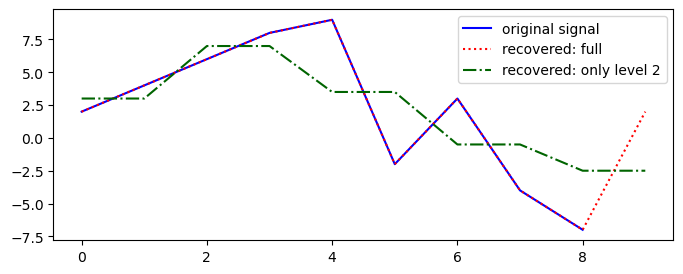

In [31]:
plt.figure(figsize=(8,3))

plt.plot(f, color = "blue", label= "original signal")

plt.plot(f_recovered2, color = "red", linestyle = ":", label= "recovered: full")

plt.plot(f_c1, color = "darkgreen", linestyle = "-.", label= "recovered: only level 2")

plt.legend()
plt.show()

### Revisit the second example

#### DWT:

In [32]:
coeffs = pywt.wavedec(noisy_sine, 'db1', level = 2, mode = 'periodic')

cA2, cD2, cD1 = coeffs

print(cA2.shape)
print(cD2.shape)
print(cD1.shape)

(250,)
(250,)
(500,)


### Reconstruct signal in full:

In [33]:
noisy_sine_rec = pywt.waverec(coeffs, 'db1', mode = 'periodic')

### Reconstruct only using cA2:

In [34]:
coeffs[-2] = np.zeros_like(coeffs[-2])

coeffs[-1] = np.zeros_like(coeffs[-1])

noisy_sine_c2 = pywt.waverec(coeffs, 'db1', mode = 'periodic')

### Reconstruct only using cD2:

In [35]:
# Decompose the again the signal
coeffs = pywt.wavedec(noisy_sine, 'db1', level = 2, mode = 'periodic')

cA2, cD2, cD1 = coeffs

# Filtering
coeffs[0] = np.zeros_like(coeffs[0])

coeffs[-1] = np.zeros_like(coeffs[-1])

noisy_sine_c3 = pywt.waverec(coeffs, 'db1', mode = 'periodic')

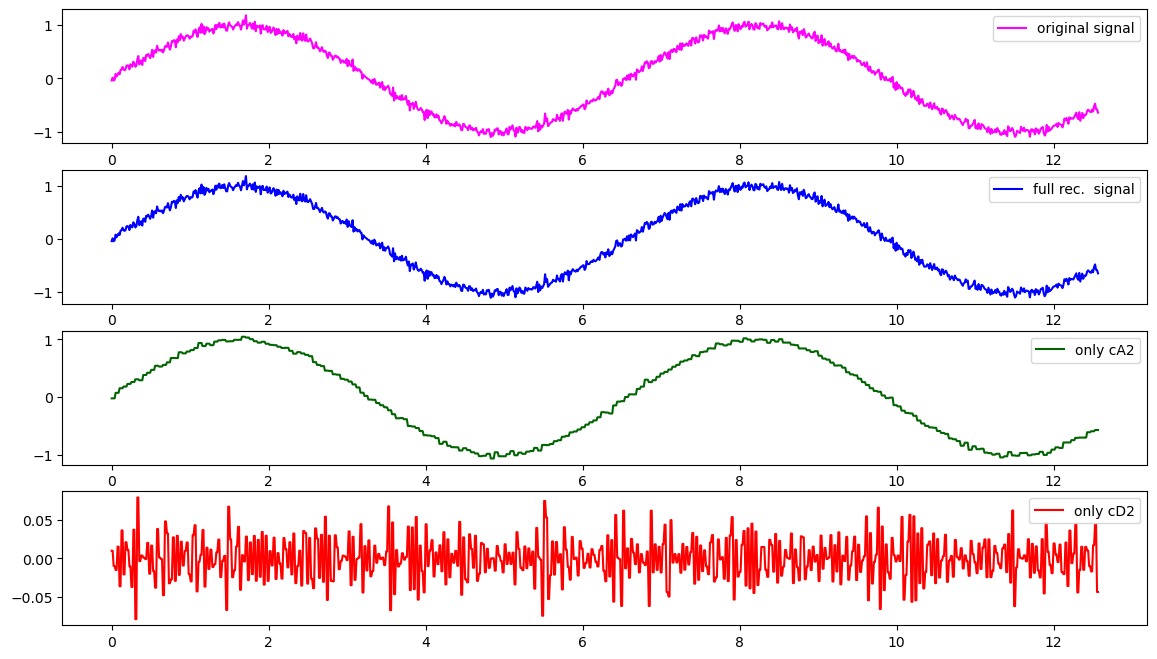

In [36]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize = (14,8))

ax1.plot(x, noisy_sine, color = "magenta", label = "original signal")
ax1.legend()

ax2.plot(x, noisy_sine_rec, linestyle = "-", color = "blue", label = "full rec.  signal")
ax2.legend()

ax3.plot(x, noisy_sine_c2, linestyle = "-", color = "darkgreen", label = "only cA2")
ax3.legend()

ax4.plot(x, noisy_sine_c3, linestyle = "-", color = "red", label = "only cD2") #we have better precision using this method
ax4.legend()

plt.show()